# Fingerprint Embedding Network — (2, 7, 33, 672) tensors

Speaker verification on STDP weight fingerprints. Consumes the ANN-ready tensors from
`prepare_fingerprints.py`: each sample `(2, 7, 33, 672)` is reshaped to model input
`(14, 33, 672)` — `2 norm (raw, z-score) × 7 input-neuron types` folded into channels,
over a `33` tonotopic-offset × `672` hidden-neuron plane.

Architecture: 2D ResNet (downsamples the 672 hidden axis hard, the 33 offset axis gently)
+ attentive statistics pooling + ArcFace (AAM-Softmax). Trained on 600 dev speakers;
evaluated **open-set** on 20 disjoint test speakers (test-internal verification: EER,
Rank-1/5, mAP via cosine).

Run all cells top-to-bottom. Requires torch, numpy, scikit-learn, matplotlib.


In [1]:
import os, sys, random, math
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ── Paths ─────────────────────────────────────────────────────────────────────
# Point INPUT_DIR at the uploaded dataset that holds dev/test_fingerprints.npz
INPUT_DIR  = "/kaggle/input/datasets/qphulong/vox1-600dev-20test"
WORK_DIR   = "/kaggle/working"
DEV_NPZ    = os.path.join(INPUT_DIR, "dev_fingerprints.npz")
TEST_NPZ   = os.path.join(INPUT_DIR, "test_fingerprints.npz")
CHECKPOINT = os.path.join(WORK_DIR,  "best_model.pth")

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Input geometry  (each fingerprint (2,7,33,672) → model input (14,33,672)) ──
IN_CH = 14    # 2 norm channels (raw, z-score) × 7 input-neuron types
H_OFF = 33    # tonotopic channel offsets -16..+16
W_HID = 672   # hidden neurons

# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM    = 256
M            = 0.2    # ArcFace margin
S            = 30     # ArcFace scale
LR           = 0.1
WEIGHT_DECAY = 5e-4
EPOCHS       = 80
P_CLASSES    = 32     # classes per PK batch
K_SAMPLES    = 4      # samples per class  → batch size = 128

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("Config OK")

Device: cuda
GPU: Tesla T4
Config OK


In [2]:
def load_split(npz_path):
    """Load (N, 2, 7, 33, 672) float16 fingerprints → (N, 14, 33, 672) float16.

    Channels 0-6  = raw weight per input-neuron type,
    channels 7-13 = z-scored per input-neuron type.
    The raw vs z-score scale mismatch is handled by the model's input BatchNorm,
    so we keep the data in float16 here (≈1.2 MB/sample) to bound memory.
    """
    d  = np.load(npz_path, allow_pickle=True)
    fp = d["fingerprints"]                                  # (N,2,7,33,672) f16
    N  = fp.shape[0]
    X  = np.ascontiguousarray(fp.reshape(N, IN_CH, H_OFF, W_HID))
    return X, d["person_ids"], d["record_ids"]

X_train, pid_train, rec_train = load_split(DEV_NPZ)
X_val,   pid_val,   rec_val   = load_split(TEST_NPZ)

# Train labels = the dev speakers (closed-set classification target).
all_persons     = sorted(set(pid_train.tolist()))
NUM_CLASSES     = len(all_persons)
person_to_label = {p: i for i, p in enumerate(all_persons)}
y_train = np.array([person_to_label[p] for p in pid_train], dtype=np.int64)

# Test speakers are DISJOINT from train (open set) → their own label space,
# used only to group same/different-speaker pairs for verification metrics.
val_persons  = sorted(set(pid_val.tolist()))
val_to_label = {p: i for i, p in enumerate(val_persons)}
y_val = np.array([val_to_label[p] for p in pid_val], dtype=np.int64)

_bc = np.bincount(y_train)
print(f"Train : {X_train.shape} {X_train.dtype}  classes={NUM_CLASSES}  "
      f"per-class min/max={_bc.min()}/{_bc.max()}")
print(f"Val   : {X_val.shape} {X_val.dtype}  classes={len(val_persons)} (disjoint, open-set)")
assert not (set(all_persons) & set(val_persons)), "train/test speakers overlap!"

Train : (19200, 14, 33, 672) float16  classes=600  per-class min/max=32/32
Val   : (320, 14, 33, 672) float16  classes=20 (disjoint, open-set)


In [3]:
class FingerprintAugment:
    """Online augmentation — applied per sample (C, H, W=672) during training."""
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clone().float()

        # Random crop along the hidden-neuron (W) axis, zero-pad back to 672
        crop_w = random.randint(576, W_HID)
        start  = random.randint(0, W_HID - crop_w)
        x      = F.pad(x[:, :, start:start + crop_w], (0, W_HID - crop_w))

        # Additive Gaussian noise (p=0.5)
        if random.random() < 0.5:
            x = x + torch.randn_like(x) * (0.01 * x.std())

        # Random amplitude scale (p=0.5)
        if random.random() < 0.5:
            x = x * random.uniform(0.95, 1.05)

        return x

In [4]:
class FingerprintDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X   = torch.from_numpy(X)            # float16 (N,14,33,672)
        self.y   = torch.from_numpy(y).long()
        self.aug = FingerprintAugment() if augment else None

    def __len__(self):  return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].float()                   # cast f16 → f32 per sample
        if self.aug is not None:
            x = self.aug(x)
        return x, self.y[idx]


class PKBatchSampler:
    """Yields batches with exactly K samples from each of P randomly chosen classes."""
    def __init__(self, labels, P, K):
        self.K   = K
        arr      = np.asarray(labels)
        self.cls_idx = defaultdict(list)
        for i, l in enumerate(arr):
            self.cls_idx[int(l)].append(i)
        self.classes   = sorted(self.cls_idx.keys())
        self.P         = min(P, len(self.classes))
        self.n_batches = max(1, len(arr) // (self.P * K))

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            for c in np.random.choice(self.classes, self.P, replace=False):
                idx = self.cls_idx[c]
                batch.extend(np.random.choice(idx, self.K,
                                              replace=(len(idx) < self.K)).tolist())
            yield batch

    def __len__(self): return self.n_batches


train_ds = FingerprintDataset(X_train, y_train, augment=True)
val_ds   = FingerprintDataset(X_val,   y_val,   augment=False)

_pin = torch.cuda.is_available()
_nw  = 2

train_loader = DataLoader(train_ds, batch_sampler=PKBatchSampler(y_train, P_CLASSES, K_SAMPLES),
                          num_workers=_nw, pin_memory=_pin)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False,
                          num_workers=_nw, pin_memory=_pin)

print(f"Train batches/epoch : {len(train_loader)}  (batch ≈ {train_loader.batch_sampler.P * K_SAMPLES})")
print(f"Val samples         : {len(val_ds)}")

Train batches/epoch : 150  (batch ≈ 128)
Val samples         : 320


In [5]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=(1, 1)):
        super().__init__()
        s = stride if isinstance(stride, tuple) else (stride, stride)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, stride=s, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.act1     = nn.PReLU(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.act2     = nn.PReLU(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=s, bias=False),
                          nn.BatchNorm2d(out_ch))
            if in_ch != out_ch or s != (1, 1) else nn.Identity()
        )

    def forward(self, x):
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act2(out + self.shortcut(x))


class AttentiveStatsPool(nn.Module):
    """Attentive mean+std pooling over the flattened spatial map.  (B,C,L) → (B,2C).

    Second-order statistics over the tonotopic map carry speaker timbre that plain
    average pooling discards.
    """
    def __init__(self, in_dim, att_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv1d(in_dim, att_dim, 1), nn.Tanh(),
            nn.Conv1d(att_dim, in_dim, 1),
        )

    def forward(self, x):                                   # x: (B, C, L)
        w     = torch.softmax(self.attention(x), dim=2)     # (B, C, L)
        mu    = (w * x).sum(dim=2)                           # (B, C)
        sigma = torch.sqrt((w * x.pow(2)).sum(dim=2).sub(mu.pow(2)).clamp(min=1e-4))
        return torch.cat([mu, sigma], dim=1)                # (B, 2C)


class FingerprintCNN(nn.Module):
    """(B, 14, 33, 672) → (B, embed_dim).

    Input BatchNorm standardises the 14 heterogeneous channels (raw weights ~[0,0.04]
    vs z-scores ~unit). A 2D ResNet downsamples the 672 hidden axis (W) hard and the
    33 offset axis (H) gently; attentive stats pooling → FC embedding (BN-normalised,
    L2-normalised at eval time).
    """
    def __init__(self, in_ch=14, embed_dim=256):
        super().__init__()
        self.in_bn = nn.BatchNorm2d(in_ch)                         # standardise inputs
        self.stem  = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=(3, 7), stride=1, padding=(1, 3), bias=False),
            nn.BatchNorm2d(32), nn.PReLU(32),
        )                                                          # (B, 32, 33, 672)
        self.block1 = ResBlock(32,  64,  stride=(1, 2))            # → (B,  64, 33, 336)
        self.block2 = ResBlock(64,  128, stride=(2, 2))            # → (B, 128, 17, 168)
        self.block3 = ResBlock(128, 256, stride=(2, 2))            # → (B, 256,  9,  84)
        self.block4 = ResBlock(256, 256, stride=(2, 2))            # → (B, 256,  5,  42)
        self.pool    = AttentiveStatsPool(256)                     # → (B, 512)
        self.dropout = nn.Dropout(p=0.4)
        self.fc      = nn.Linear(512, embed_dim, bias=False)
        self.bn      = nn.BatchNorm1d(embed_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.in_bn(x)
        x = self.stem(x)
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.block4(x)
        x = x.flatten(2)              # (B, 256, H*W)
        x = self.pool(x)             # (B, 512)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.bn(x)
        return x                     # (B, embed_dim) — BN-normalised, not yet L2-normalised


class AAMSoftmax(nn.Module):
    """Additive Angular Margin Softmax (ArcFace), with the standard easy-margin guard."""
    def __init__(self, embed_dim, num_classes, m=0.2, s=30):
        super().__init__()
        self.s     = s
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m
        self.W     = nn.Parameter(torch.empty(num_classes, embed_dim))
        nn.init.xavier_normal_(self.W)

    def forward(self, embeddings, labels):
        cos = F.linear(F.normalize(embeddings), F.normalize(self.W)).clamp(-1 + 1e-7, 1 - 1e-7)
        sin = torch.sqrt((1.0 - cos.pow(2)).clamp(min=1e-7))
        phi = cos * self.cos_m - sin * self.sin_m                # cos(theta + m)
        phi = torch.where(cos > self.th, phi, cos - self.mm)     # monotonicity guard
        oh  = F.one_hot(labels, num_classes=self.W.size(0)).float()
        logits = (oh * phi + (1.0 - oh) * cos) * self.s
        return F.cross_entropy(logits, labels)


model = FingerprintCNN(IN_CH, embed_dim=EMBED_DIM).to(DEVICE)
aam   = AAMSoftmax(EMBED_DIM, NUM_CLASSES, m=M, s=S).to(DEVICE)
total = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in aam.parameters())
print(f"Total params: {total:,}  (~{total/1e6:.2f}M)")

with torch.no_grad():
    dummy = torch.randn(4, IN_CH, H_OFF, W_HID, device=DEVICE)
    print("Embedding shape:", model(dummy).shape)   # expect (4, EMBED_DIM)

Total params: 2,815,676  (~2.82M)
Embedding shape: torch.Size([4, 256])


In [6]:
# Open-set verification metrics — computed WITHIN the disjoint test set.
# Every test embedding is both a query and a gallery item; self-matches are masked.

@torch.no_grad()
def encode_all(loader, mdl):
    mdl.eval()
    embs, lbls = [], []
    for x, y in loader:
        e = F.normalize(mdl(x.to(DEVICE)), dim=1)
        embs.append(e.cpu())
        lbls.append(y)
    return torch.cat(embs), torch.cat(lbls)


def _sim_no_self(emb):
    s = emb @ emb.t()
    s.fill_diagonal_(-2.0)          # exclude self-match from retrieval
    return s


def rank_k(emb, lbl, k=1):
    s    = _sim_no_self(emb)
    k    = min(k, emb.size(0) - 1)
    topk = s.topk(k, dim=1).indices
    hit  = (lbl[topk] == lbl.unsqueeze(1)).any(1)
    return hit.float().mean().item()


def compute_map(emb, lbl):
    s   = _sim_no_self(emb)
    aps = []
    for i in range(emb.size(0)):
        order = s[i].argsort(descending=True)
        rel   = (lbl[order] == lbl[i]).float()
        n_rel = rel.sum().item()
        if n_rel == 0:
            continue
        cum = rel.cumsum(0)
        pos = torch.arange(1, len(rel) + 1, dtype=torch.float32)
        aps.append(((cum / pos) * rel).sum().item() / n_rel)
    return float(np.mean(aps)) if aps else 0.0


def compute_eer(emb, lbl):
    s  = emb @ emb.t()
    n  = emb.size(0)
    iu = torch.triu_indices(n, n, offset=1)             # unique pairs, no self
    scores = s[iu[0], iu[1]].numpy()
    same   = (lbl[iu[0]] == lbl[iu[1]]).numpy().astype(float)
    pos, neg = same.sum(), len(same) - same.sum()
    best, best_d = 0.5, float("inf")
    for t in np.linspace(scores.min(), scores.max(), 300):
        pred = (scores >= t).astype(float)
        far  = ((pred == 1) & (same == 0)).sum() / (neg + 1e-10)
        frr  = ((pred == 0) & (same == 1)).sum() / (pos + 1e-10)
        d    = abs(far - frr)
        if d < best_d:
            best_d, best = d, (far + frr) / 2
    return float(best)

print("Eval utilities loaded (open-set, test-internal verification).")

Eval utilities loaded (open-set, test-internal verification).


In [7]:
def build_optimizer(mdl, aam_head, lr, wd):
    """Apply weight-decay only to conv/linear weights, not BN/PReLU/biases."""
    no_wd_types = (nn.BatchNorm1d, nn.BatchNorm2d, nn.PReLU)
    decay, no_decay = [], []
    for module in list(mdl.modules()) + list(aam_head.modules()):
        if isinstance(module, no_wd_types):
            no_decay.extend(module.parameters(recurse=False))
        elif hasattr(module, "weight") and module.weight is not None and not isinstance(module, no_wd_types):
            if module.weight.requires_grad:
                decay.append(module.weight)
        if hasattr(module, "bias") and module.bias is not None:
            if module.bias.requires_grad:
                no_decay.append(module.bias)
    # AAMSoftmax.W is an nn.Parameter (not a module weight) → add it to the decay group.
    decay.append(aam_head.W)
    seen = set()
    decay    = [p for p in decay    if id(p) not in seen and not seen.add(id(p))]
    no_decay = [p for p in no_decay if id(p) not in seen and not seen.add(id(p))]
    return SGD([{"params": decay,    "weight_decay": wd},
                {"params": no_decay, "weight_decay": 0.0}],
               lr=lr, momentum=0.9, nesterov=True)


optimizer = build_optimizer(model, aam, LR, WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history    = {"loss": [], "rank1": [], "rank5": [], "eer": [], "map": []}
best_rank1 = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train(); aam.train()
    total_loss = 0.0; n_batches = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = aam(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); n_batches += 1
    scheduler.step()
    avg_loss = total_loss / max(n_batches, 1)

    # ── Eval (open-set, test-internal) ─────────────────────────────────────────
    emb, lbl = encode_all(val_loader, model)
    r1  = rank_k(emb, lbl, k=1)
    r5  = rank_k(emb, lbl, k=5)
    eer = compute_eer(emb, lbl)
    mAP = compute_map(emb, lbl)
    for k, v in zip(("loss", "rank1", "rank5", "eer", "map"),
                    (avg_loss, r1, r5, eer, mAP)):
        history[k].append(v)

    # ── Checkpoint on best Rank-1 ──────────────────────────────────────────────
    marker = ""
    if r1 > best_rank1:
        best_rank1 = r1
        torch.save({"model": model.state_dict(), "aam": aam.state_dict(),
                    "epoch": epoch, "rank1": r1, "eer": eer}, CHECKPOINT)
        marker = " ★"

    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS}  loss={avg_loss:.4f}  "
              f"R@1={r1:.3f}  R@5={r5:.3f}  EER={eer:.3f}  mAP={mAP:.3f}{marker}")

print(f"\nBest Rank-1: {best_rank1:.3f}  saved → {CHECKPOINT}")

Ep   1/80  loss=13.5493  R@1=0.387  R@5=0.700  EER=0.363  mAP=0.202 ★
Ep   5/80  loss=11.1738  R@1=0.637  R@5=0.884  EER=0.299  mAP=0.289 ★
Ep  10/80  loss=8.6328  R@1=0.781  R@5=0.941  EER=0.270  mAP=0.354 ★
Ep  15/80  loss=7.4657  R@1=0.747  R@5=0.934  EER=0.259  mAP=0.368
Ep  20/80  loss=7.3275  R@1=0.719  R@5=0.928  EER=0.249  mAP=0.343
Ep  25/80  loss=7.1431  R@1=0.525  R@5=0.822  EER=0.278  mAP=0.265
Ep  30/80  loss=7.1427  R@1=0.331  R@5=0.678  EER=0.293  mAP=0.190
Ep  35/80  loss=7.1373  R@1=0.278  R@5=0.597  EER=0.309  mAP=0.163
Ep  40/80  loss=7.0945  R@1=0.203  R@5=0.512  EER=0.307  mAP=0.153
Ep  45/80  loss=7.0760  R@1=0.216  R@5=0.547  EER=0.306  mAP=0.161
Ep  50/80  loss=7.0294  R@1=0.156  R@5=0.541  EER=0.313  mAP=0.139
Ep  55/80  loss=6.9984  R@1=0.144  R@5=0.469  EER=0.326  mAP=0.143
Ep  60/80  loss=6.9678  R@1=0.125  R@5=0.491  EER=0.324  mAP=0.140
Ep  65/80  loss=6.9224  R@1=0.084  R@5=0.431  EER=0.325  mAP=0.135
Ep  70/80  loss=6.8959  R@1=0.103  R@5=0.419  EER=0.33

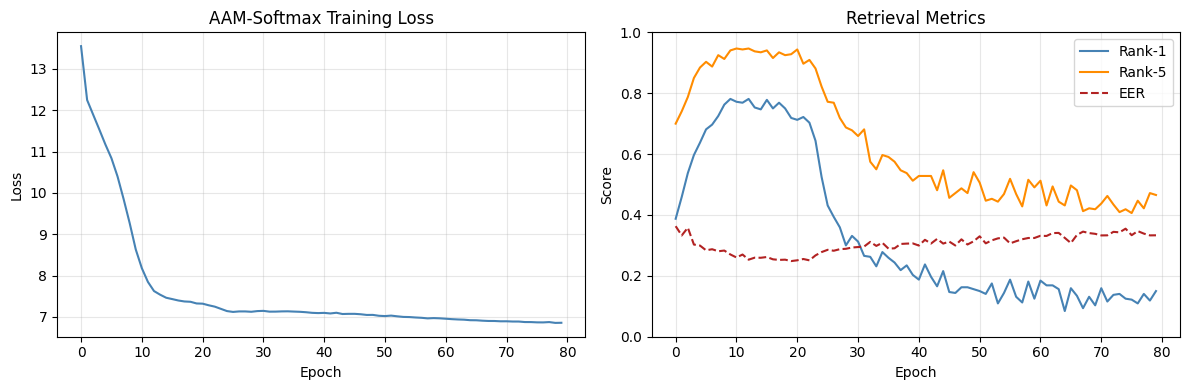

Final — R@1=0.150  R@5=0.466  EER=0.333  mAP=0.131


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], color="steelblue")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="AAM-Softmax Training Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history["rank1"], label="Rank-1", color="steelblue")
axes[1].plot(history["rank5"], label="Rank-5", color="darkorange")
axes[1].plot(history["eer"],   label="EER",    color="firebrick",  linestyle="--")
axes[1].set(xlabel="Epoch", ylabel="Score", title="Retrieval Metrics", ylim=(0, 1))
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(CHECKPOINT), "training_curves.png"), dpi=120)
plt.show()
print(f"Final — R@1={history['rank1'][-1]:.3f}  R@5={history['rank5'][-1]:.3f}  "
      f"EER={history['eer'][-1]:.3f}  mAP={history['map'][-1]:.3f}")


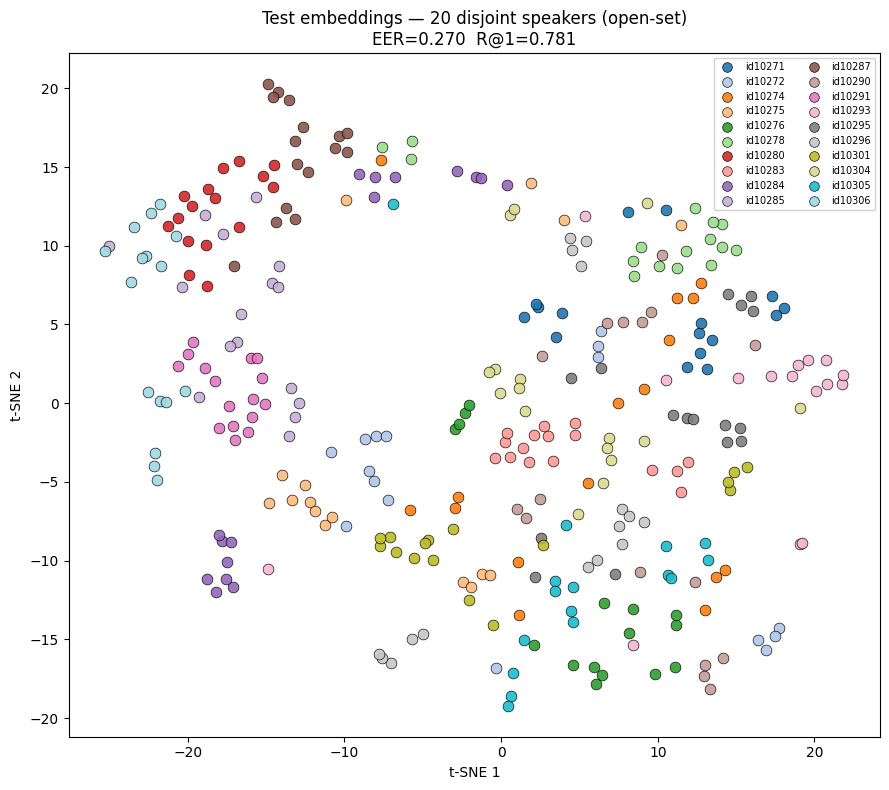

Saved → /kaggle/working/tsne_test.png


In [9]:
# t-SNE of the test embeddings, coloured by the (disjoint) test speaker.
# Tight, well-separated per-speaker clusters → good open-set verification.
import matplotlib as mpl

ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])

emb, lbl = encode_all(val_loader, model)               # val_loader is shuffle=False
assert np.array_equal(lbl.numpy(), y_val), "embedding order misaligned with labels"
emb_np = emb.numpy()

perp   = min(30, len(emb_np) - 1)
coords = TSNE(n_components=2, perplexity=perp, init="pca",
              random_state=42).fit_transform(emb_np)

pid_arr = np.asarray(pid_val)
cmap    = mpl.colormaps["tab20"].resampled(len(val_persons))

fig, ax = plt.subplots(figsize=(9, 8))
for i, person in enumerate(val_persons):
    m = pid_arr == person
    ax.scatter(coords[m, 0], coords[m, 1], color=cmap(i), s=60,
               edgecolors="black", linewidths=0.5, alpha=0.9, label=person)

ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2",
       title=f"Test embeddings — {len(val_persons)} disjoint speakers (open-set)\n"
             f"EER={ckpt.get('eer', float('nan')):.3f}  "
             f"R@1={ckpt.get('rank1', float('nan')):.3f}")
ax.legend(ncol=2, fontsize=7, markerscale=0.9, loc="best", framealpha=0.9)
plt.tight_layout()
out_path = os.path.join(WORK_DIR, "tsne_test.png")
plt.savefig(out_path, dpi=120)
plt.show()
print(f"Saved → {out_path}")